<a href="https://colab.research.google.com/github/ys23-lys/ESAA/blob/main/ESAA_OB_WEEK10_%ED%95%84%EC%82%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 딥러닝 파이토치 p.360-371 필사

RNN 실습 코드도 같은 링크에 필사

## 7.1 시계열 문제

시계열 분석: 시간에 따라 변하는 데이터를 사용하여 추이를 분석하는 것. 추세 파악, 향후 전망 에측을 위한 용도로 시계열 분석 사용.

시계열 형태(the components of time series)
- 불규칙 변동(irregular variation): 시간에 따른 규칙적인 움직임과 달리 어떤 규칙성이 없어 예측 불가능하고 우연적으로 발생하는 변동.
- 추세변동(trend variation): 장기적인 변화 추세. 장기간에 걸쳐 지속적으로 증가, 감소하거나 또는 일정한 상태를 유지하려는 성향을 의미하기 때문에 짧은 기간 동안에는 추세 변동을 찾기 어려움.
- 순환 변동(seasonal variation): 계절적 영향과 사회적 관습에 따라 1년 주기로 발생하는 것을 의미. 계절에 따라 순환하며 변동하는 특성이 있음.

불규칙적 시계열 데이터에 규칙성을 부여하는 방법으로 AR, MA, ARMA, ARIMA 모델을 적용할 수 있음.

## 7.2 AR, MA, ARMA, ARIMA

시계열 분석은 독립 변수를 사용하여 종속 변수를 예측하는 일반적인 머신 러닝에서 시간을 독립 변수로 사용한다는 특징이 있음.

### 7.2.1 AR 모델

AR(AutoRegressive;자기회귀) 모델: 이전 관측 값이 이후 관측 값에 영향을 준다는 아이디어에 대한 모형, 자기 회귀 모델.
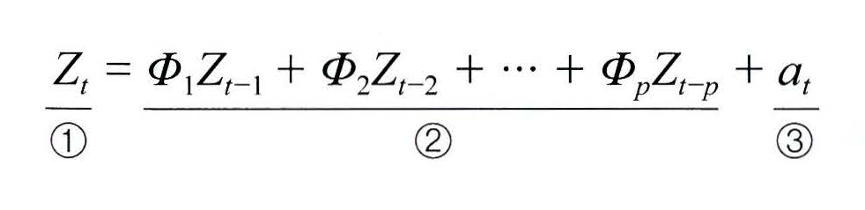

1: 시계열 데이터에서 현재 시점을 의미.

2: 과거가 현재에 미치는 영향을 나타내는 모수*시계열 데이터의 과거 시점

3: 시계열 분석에서 오차 항을 의미. 백색 잡음.

p 시점을 기준으로 그 이전의 데이터에 의해 현재 시점의 데이터가 영향을 받는 모형.

### 7.2.2 MA 모델

MA(Moving Average;이동평균) 모델: 트렌드가 변화하는 상황에 적합한 회귀 모델. 윈도우라는 개념을 사용하며, 시계열을 따라 윈도우 크기만큼 슬라이딩된다고 하여 이동 평균 모델이라 함.

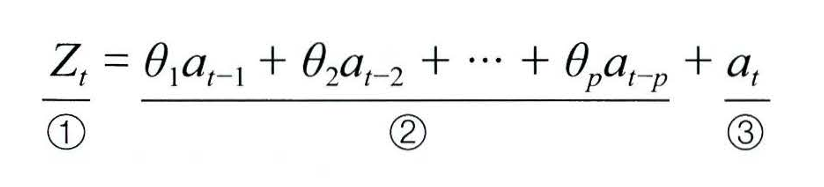

1: 시계열 데이터에서 현재 시점을 의미.

2: 매개변수*과거 시점의 오차

3: 오차 항

이전 데이터의 오차에서 현재 데이터의 상태를 추론.

### 7.2.3 ARMA 모델

ARMA(AutoRegressive Moving Average;자기회귀이동평균) 모델: AR과 MA를 섞은 모델.

### 7.2.4 ARIMA 모델

ARIMA(AutoRegressive Integrated Moving Average;자기회귀누적이동평균) 모델: 과거 데이터의 선형 관계뿐 아니라 추세까지 고려한 모델.

1. ARIMA() 함수를 호출. ARIMA(p: 자기 회귀 차수, d: 차분 차수, q: 이동 평균 차수)
2. fit() 메서드 호출, 모델에 데이터를 적용하여 훈련.
3. predict() 메서드 호출. 미래의 추세 및 동향 예측.

statsmodels 라이브러리
- 검정 및 추정, 회귀 분석, 시계열 분석 등의 통계 분석 기능을 제공하는 파이썬 패키지.

In [5]:
!git clone https://github.com/gilbutITbook/080289.git

Cloning into '080289'...
remote: Enumerating objects: 2278, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 2278 (delta 1), reused 0 (delta 0), pack-reused 2273 (from 2)
Receiving objects: 100% (2278/2278), 330.30 MiB | 38.53 MiB/s, done.
Resolving deltas: 100% (13/13), done.
Updating files: 100% (2591/2591), done.


In [6]:
data_path='080289/chap07/data/sales'

/tmp/ipykernel_2484/1833658511.py:10: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  series=read_csv(data_path + '.csv',header=0,parse_dates=[0],index_col=0,date_parser=parser)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   36
Model:                 ARIMA(5, 1, 0)   Log Likelihood                -199.651
Date:                Tue, 05 May 2026   AIC                            411.302
Time:                        08:37:43   BIC                            420.634
Sample:                    01-01-1991   HQIC                           414.523
                         - 12-01-1993                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8788      0.227     -3.876      0.000      -1.323      -0.434
ar.L2         -0.2787      0.232     -1.203      0.229      -0.733       0.176
ar.L3         -0.0076      0.270     -0.028      0.9

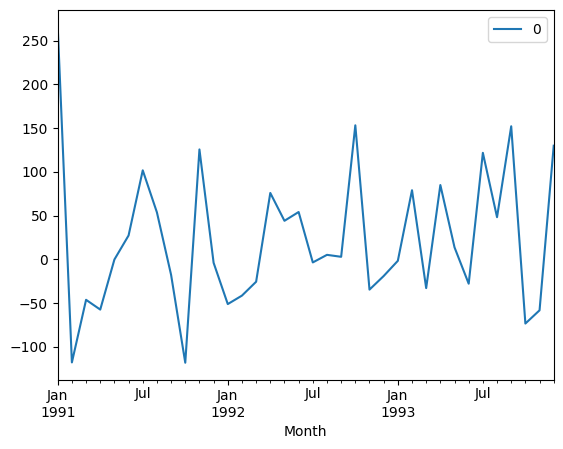

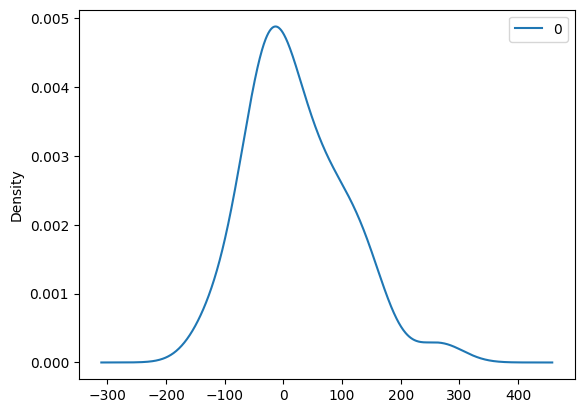

                0
count   36.000000
mean    22.459086
std     82.505331
min   -118.213281
25%    -33.308343
50%      1.361178
75%     76.704967
max    266.000000


In [8]:
# 코드 7-1 ARIMA() 함수를 호출하여 sales 데이터셋에 대한 예측
from pandas import read_csv, DataFrame
from datetime import datetime
from statsmodels.tsa.arima.model import ARIMA
from matplotlib import pyplot

def parser(x):
  return datetime.strptime('199'+x,'%Y-%m')

series=read_csv(data_path + '.csv',header=0,parse_dates=[0],index_col=0,date_parser=parser)
model=ARIMA(series,order=(5,1,0))
model_fit=model.fit()
print(model_fit.summary())
residuals=DataFrame(model_fit.resid)
residuals.plot()
pyplot.show()
residuals.plot(kind='kde')
pyplot.show()
print(residuals.describe())

/tmp/ipykernel_2484/1370174586.py:12: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  series=read_csv(data_path + '.csv',header=0,parse_dates=[0],index_col=0,date_parser=parser)
/tmp/ipykernel_2484/1370174586.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('predicted=%f,expected=%f'%(yhat,obs))


predicted=352.855343,expected=346.300000
predicted=277.398036,expected=329.700000
predicted=368.753734,expected=445.400000
predicted=331.773634,expected=325.900000
predicted=372.070405,expected=449.300000
predicted=360.020872,expected=411.300000
predicted=454.526230,expected=417.400000
predicted=388.690691,expected=545.500000
predicted=437.632447,expected=477.600000
predicted=516.437624,expected=687.000000
predicted=520.916191,expected=435.300000
predicted=675.594647,expected=587.300000
predicted=505.201016,expected=676.900000
Test MSE:9118.819


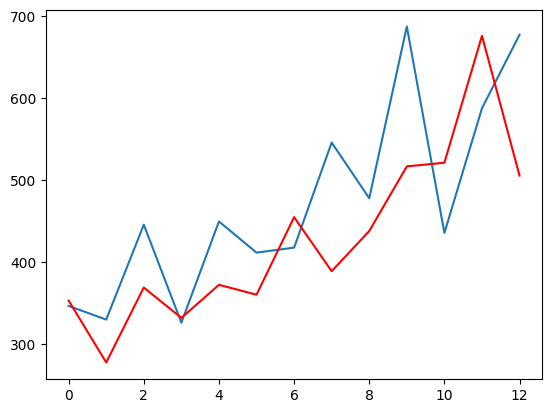

In [9]:
# 코드 7-2 statsmodels 라이브러리를 이용한 sales 데이터셋 예측
import numpy as np
from pandas import read_csv, DataFrame
from datetime import datetime
from matplotlib import pyplot
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

def parser(x):
  return datetime.strptime('199'+x,'%Y-%m')

series=read_csv(data_path + '.csv',header=0,parse_dates=[0],index_col=0,date_parser=parser)
X=series.values
X=np.nan_to_num(X)
size=int(len(X)*0.66)
train,test=X[0:size],X[size:len(X)]
history=[x for x in train]
predictions=list()
for t in range(len(test)):
  model=ARIMA(history,order=(5,1,0))
  model_fit=model.fit()
  output=model_fit.forecast()
  yhat=output[0]
  predictions.append(yhat)
  obs=test[t]
  history.append(obs)
  print('predicted=%f,expected=%f'%(yhat,obs))
error=mean_squared_error(test,predictions)
print('Test MSE:%.3f'%error)
pyplot.plot(test)
pyplot.plot(predictions,color='red')
pyplot.show()

## 7.3 순환 신경망(RNN)

RNN(Recurrent Neural Network): 시간적으로 연속성이 있는 데이터를 처리하려고 고안된 인공 신경망. 이전 은닉층이 현재 은닉층의 입력이 되면서 반복되는 순환 구조를 가짐. 최종적으로 남겨진 기억이 모든 입력 전체를 요약한 정보가 됨.
1. 일대일: 순환 없음. 순방향 네트워크
2. 일대다: 입력 하나, 출력 다수. 이미지를 입력해 이미지에 대한 설명을 문장으로 출력하는 이미지 캡션이 대표적.
3. 다대일: 입력 다수, 출력 하나. 문장을 입력해 긍/부정을 출력하는 감성 분석기에서 사용.
4. 다대다: 입출력 다수. 언어를 번역하는 자동 번역기가 대표적.
5. 동기화 다대다: 문장에서 다음에 나올 단어를 예측하는 언어 모델, 즉 프레임 수준의 비디오 분류가 대표적.

### 7.3.1 RNN 계층과 셀

RNN 계층: 입력된 배치를 순서대로 모두 처리. 셀을 래핑하여 동일한 셀을 여러 단계에 적용.

RNN 셀: 하나의 단계만 처리.
- nn.RNNCell
- nn.GRUCell
- nn.LSTMCell


# RNN 실습 코드

### 1. 문자 단위 RNN(Char RNN)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

#### 1) 훈련 데이터 전처리

입력 데이터와 레이블 데이터에 대해 문자 집합을 만듦. - 중복을 제거한 문자들의 집합.

In [2]:
input_str='apple'
label_str='pple!'
char_vocab=sorted(list(set(input_str+label_str)))
vocab_size=len(char_vocab)
print('문자 집합의 크기:{}'.format(vocab_size))

문자 집합의 크기:5


In [3]:
input_size=vocab_size # 입력의 크기는 문자 집합의 크기
hidden_size=5
output_size=5
learning_rate=0.1

In [4]:
char_to_index = dict((c,i) for i,c in enumerate(char_vocab)) # 문자에 고유한 정수 인덱스 부여
print(char_to_index)

{'!': 0, 'a': 1, 'e': 2, 'l': 3, 'p': 4}


In [5]:
index_to_char={}
for key, value in char_to_index.items():
    index_to_char[value]=key
print(index_to_char)

{0: '!', 1: 'a', 2: 'e', 3: 'l', 4: 'p'}


In [6]:
x_data=[char_to_index[c] for c in input_str]
y_data=[char_to_index[c] for c in label_str]
print(x_data)
print(y_data)

[1, 4, 4, 3, 2]
[4, 4, 3, 2, 0]


In [7]:
# 배치 차원 추가
# 텐서 연산인 unsqueeze(0)를 통해 해결할 수도 있었음.
x_data=[x_data]
y_data=[y_data]
print(x_data)
print(y_data)

[[1, 4, 4, 3, 2]]
[[4, 4, 3, 2, 0]]


In [8]:
x_one_hot=[np.eye(vocab_size)[x] for x in x_data]
print(x_one_hot)

[array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 1., 0.],
       [0., 0., 1., 0., 0.]])]


In [9]:
X=torch.FloatTensor(x_one_hot)
Y=torch.LongTensor(y_data)

/tmp/ipykernel_5100/992893729.py:1: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  X=torch.FloatTensor(x_one_hot)


In [10]:
print('훈련 데이터의 크기:{}'.format(X.shape))
print('레이블의 크기:{}'.format(Y.shape))

훈련 데이터의 크기:torch.Size([1, 5, 5])
레이블의 크기:torch.Size([1, 5])


#### 2) 모델 구현하기

fc: 완전 연결층. 출력층으로 사용.

In [11]:
class Net(torch.nn.Module):
    def __init__(self,input_size,hidden_size,output_size):
        super(Net,self).__init__()
        self.rnn=torch.nn.RNN(input_size,hidden_size,batch_first=True) # RNN 셀 구현
        self.fc=torch.nn.Linear(hidden_size,output_size,bias=True) # 출력층 구현

    def forward(self,x): # 구현한 RNN 셀과 출력층을 연결
        x,_status=self.rnn(x)
        x=self.fc(x)
        return x

In [12]:
net=Net(input_size,hidden_size,output_size)

In [13]:
outputs=net(X)
print(outputs.shape) # 3차원 텐서

torch.Size([1, 5, 5])


In [14]:
print(outputs.view(-1,input_size).shape) # 2차원 텐서로 변환

torch.Size([5, 5])


In [15]:
print(Y.shape)
print(Y.view(-1).shape)

torch.Size([1, 5])
torch.Size([5])


In [16]:
criterion=torch.nn.CrossEntropyLoss()
optimizer=optim.Adam(net.parameters(),learning_rate)

In [17]:
for i in range(100):
    optimizer.zero_grad()
    outputs=net(X)
    loss=criterion(outputs.view(-1,input_size),Y.view(-1)) # view를 하는 이유는 Batch 차원 제거를 위해
    loss.backward() # 기울기 계산
    optimizer.step() # 아까 optimizer 선언 시 넣어둔 파라미터 업데이트

    # 아래 세 줄은 모델이 실제 어떻게 예측했는지를 확인하기 위한 코드.
    result=outputs.data.numpy().argmax(axis=2) # 최종 예측값인 각 time-step 별 5차원 벡터에 대해서 가장 높은 값의 인덱스를 선택
    result_str=''.join([index_to_char[c] for c in np.squeeze(result)])
    print(i,"loss:",loss.item(),"prediction:",result,"true Y:",y_data,"prediction str:",result_str)

0 loss: 1.6779346466064453 prediction: [[0 0 0 3 0]] true Y: [[4, 4, 3, 2, 0]] prediction str: !!!l!
1 loss: 1.3712339401245117 prediction: [[2 0 3 2 0]] true Y: [[4, 4, 3, 2, 0]] prediction str: e!le!
2 loss: 1.118882417678833 prediction: [[4 4 3 2 0]] true Y: [[4, 4, 3, 2, 0]] prediction str: pple!
3 loss: 0.8448923230171204 prediction: [[4 4 3 2 0]] true Y: [[4, 4, 3, 2, 0]] prediction str: pple!
4 loss: 0.5945357084274292 prediction: [[4 4 3 2 0]] true Y: [[4, 4, 3, 2, 0]] prediction str: pple!
5 loss: 0.4345654845237732 prediction: [[4 4 3 2 0]] true Y: [[4, 4, 3, 2, 0]] prediction str: pple!
6 loss: 0.3142085671424866 prediction: [[4 4 3 2 0]] true Y: [[4, 4, 3, 2, 0]] prediction str: pple!
7 loss: 0.22181996703147888 prediction: [[4 4 3 2 0]] true Y: [[4, 4, 3, 2, 0]] prediction str: pple!
8 loss: 0.15716248750686646 prediction: [[4 4 3 2 0]] true Y: [[4, 4, 3, 2, 0]] prediction str: pple!
9 loss: 0.10353950411081314 prediction: [[4 4 3 2 0]] true Y: [[4, 4, 3, 2, 0]] prediction

### 2. 더 많은 데이터로 학습한 문자 단위 RNN(Char RNN)

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim

#### 1) 훈련 데이터 전처리하기

In [19]:
sentence=("if you want to build a ship, don't drum up people together to "
            "collect wood and don't assign them tasks and work, but rather "
            "teach them to long for the endless immensity of the sea.")

In [20]:
char_set=list(set(sentence)) # 중복을 제거한 문자 집합 생성
char_dic={c: i for i,c in enumerate(char_set)} # 각 문자에 정수 인코딩

In [21]:
print(char_dic) # 공백도 여기서는 하나의 원소

{'y': 0, '.': 1, 'o': 2, 'h': 3, 'd': 4, 'f': 5, 'r': 6, 'c': 7, ' ': 8, 'm': 9, 'k': 10, ',': 11, 'g': 12, 'p': 13, 'u': 14, 'n': 15, 'w': 16, "'": 17, 'a': 18, 'l': 19, 't': 20, 'e': 21, 'i': 22, 's': 23, 'b': 24}


In [22]:
dic_size=len(char_dic)
print('문자 집합의 크기:{}'.format(dic_size))

문자 집합의 크기:25


In [23]:
# 하이퍼파라미터 설정
hidden_size=dic_size
sequence_length=10  # 임의 숫자 지정
learning_rate=0.1

In [24]:
# 데이터 구성
x_data=[]
y_data=[]

for i in range(0,len(sentence)-sequence_length):
    x_str=sentence[i:i+sequence_length]
    y_str=sentence[i+1:i+sequence_length+1]
    print(i,x_str,'->',y_str)

    x_data.append([char_dic[c] for c in x_str])  # x str to index
    y_data.append([char_dic[c] for c in y_str])  # y str to index

0 if you wan -> f you want
1 f you want ->  you want 
2  you want  -> you want t
3 you want t -> ou want to
4 ou want to -> u want to 
5 u want to  ->  want to b
6  want to b -> want to bu
7 want to bu -> ant to bui
8 ant to bui -> nt to buil
9 nt to buil -> t to build
10 t to build ->  to build 
11  to build  -> to build a
12 to build a -> o build a 
13 o build a  ->  build a s
14  build a s -> build a sh
15 build a sh -> uild a shi
16 uild a shi -> ild a ship
17 ild a ship -> ld a ship,
18 ld a ship, -> d a ship, 
19 d a ship,  ->  a ship, d
20  a ship, d -> a ship, do
21 a ship, do ->  ship, don
22  ship, don -> ship, don'
23 ship, don' -> hip, don't
24 hip, don't -> ip, don't 
25 ip, don't  -> p, don't d
26 p, don't d -> , don't dr
27 , don't dr ->  don't dru
28  don't dru -> don't drum
29 don't drum -> on't drum 
30 on't drum  -> n't drum u
31 n't drum u -> 't drum up
32 't drum up -> t drum up 
33 t drum up  ->  drum up p
34  drum up p -> drum up pe
35 drum up pe -> rum up peo
36

In [25]:
print(x_data[0])
print(y_data[0])

[22, 5, 8, 0, 2, 14, 8, 16, 18, 15]
[5, 8, 0, 2, 14, 8, 16, 18, 15, 20]


In [26]:
x_one_hot=[np.eye(dic_size)[x] for x in x_data] # x 데이터는 원-핫 인코딩
X=torch.FloatTensor(x_one_hot)
Y=torch.LongTensor(y_data)

In [28]:
print('훈련 데이터의 크기:{}'.format(X.shape))
print('레이블의 크기:{}'.format(Y.shape))

훈련 데이터의 크기:torch.Size([170, 10, 25])
레이블의 크기:torch.Size([170, 10])


In [29]:
print(X[0])

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 1., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
         0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,

In [30]:
print(Y[0])

tensor([ 5,  8,  0,  2, 14,  8, 16, 18, 15, 20])


#### 2) 모델 구현하기

은닉층 2개 - nn.RNN() 안에 num_layers로 은닉층 개수를 선언.

In [31]:
class Net(torch.nn.Module):
    def __init__(self,input_dim,hidden_dim,layers): # 현재 hidden_size는 dic_size와 같음.
        super(Net,self).__init__()
        self.rnn=torch.nn.RNN(input_dim,hidden_dim,num_layers=layers,batch_first=True)
        self.fc=torch.nn.Linear(hidden_dim,hidden_dim,bias=True)

    def forward(self,x):
        x,_status=self.rnn(x)
        x=self.fc(x)
        return x

In [32]:
net=Net(dic_size,hidden_size,2) # 이번에는 층을 두 개 쌓습니다.

In [33]:
criterion=torch.nn.CrossEntropyLoss()
optimizer=optim.Adam(net.parameters(),learning_rate)

In [34]:
outputs=net(X)
print(outputs.shape) # 3차원 텐서

torch.Size([170, 10, 25])


In [35]:
print(outputs.view(-1,dic_size).shape) # 2차원 텐서로 변환.

torch.Size([1700, 25])


In [36]:
print(Y.shape)
print(Y.view(-1).shape)

torch.Size([170, 10])
torch.Size([1700])


In [37]:
for i in range(100):
    optimizer.zero_grad()
    outputs=net(X) # (170,10,25) 크기를 가진 텐서를 매 에포크마다 모델의 입력으로 사용
    loss=criterion(outputs.view(-1,dic_size),Y.view(-1))
    loss.backward()
    optimizer.step()

    # results의 텐서 크기는 (170,10)
    results=outputs.argmax(dim=2)
    predict_str=""
    for j,result in enumerate(results):
        if j==0: # 처음에는 예측 결과를 전부 가져오지만
            predict_str += ''.join([char_set[t] for t in result])
        else: # 그 다음에는 마지막 글자만 반복 추가
            predict_str += char_set[result[-1]]

    print(predict_str)

o,,o,,o,,o,o,,o,,oo,o,o,,o,,o,ooo,o,,ooo,o,,,oo,nooo,o,oo,o,oo,,oonooo,,o,o,o,,,,oo,o,,,o,oo,oo,oo,o,,,,o,,,,,,,,,,oo,oooo,o,o,,,o,,o,oooo,,o,,,,,o,oo,oo,,nooo,,,noo,,o,,,,,ooo,,,
         t tk t     t t                t  t      t  t     t  tt    t t    t t t      t      t      t  ttt t     tt  t  k   t  tt t       t    t  t    t       t         t      t  t
                            a     a                        a                                     a            a  h     h    a     h    h                                           
 ty.n t,.fe  ee      fn e eea   e a   e e a nnen eae  en   ae  fe   an ne   fn  nfa e aee  efe  efn  fata a n   nfe  oa e aea   fn e e en  ee   ne  n e a   ff   eefn   ffe  efn  e
 tdoe ,od iod doi  i dto  d iotodoe ioi i do t i oi  tod doi  tid ioi oto  d e tt iot i i ioi ot   dteioi ioioiot i ,oioioi i dtidoioi o todd ioi  d  doi ioi  o   d  i   e oi eot 
  t e t t t tttttt t tt   t t t t t t t tttttttt tt  t t t tttttttt tt t ttt tttt t t t t t tt ttttt